# Decision Tree Classifier

## 1. Problem Statement
The objective is to predict whether a passenger survived the Titanic disaster using the Decision Tree Classification algorithm. The Titanic dataset from Seaborn is used for this task.

# 2. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score

Matplotlib is building the font cache; this may take a moment.


## 3. Dataset Loading

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 4. Exploratory Data Analysis (EDA)

In [3]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

Shape: (891, 15)

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Data Types:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Statistical Summary:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.83

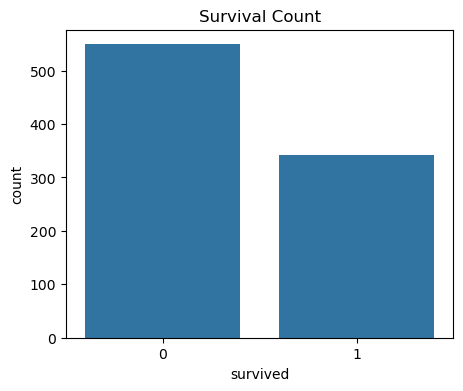

In [4]:
plt.figure(figsize=(5,4))
sns.countplot(x='survived', data=df)
plt.title("Survival Count")
plt.show()

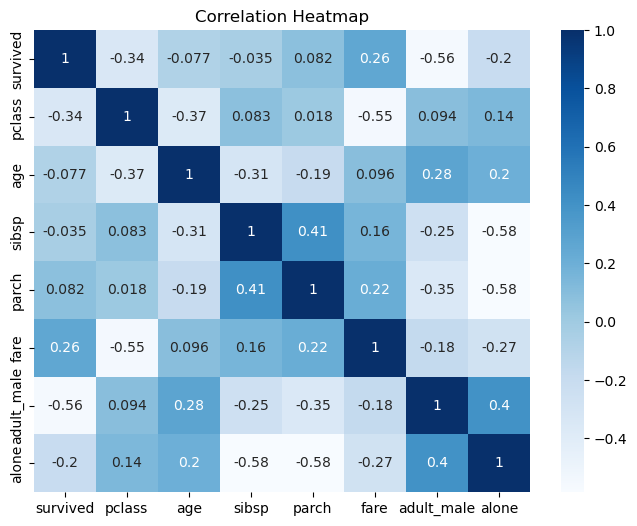

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

## 5. Data Preprocessing

In [ ]:
df = df[['survived','pclass','sex','age','fare','sibsp','parch','embarked']]

df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 6. Model Building

In [7]:
model = DecisionTreeClassifier(random_state=42)

## 7. Model Training

In [8]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

## 8. Model Evaluation

In [9]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_prob))

Accuracy : 0.7877094972067039
Precision: 0.7432432432432432
Recall   : 0.7432432432432432
F1 Score : 0.7432432432432432
AUC Score: 0.8073359073359073


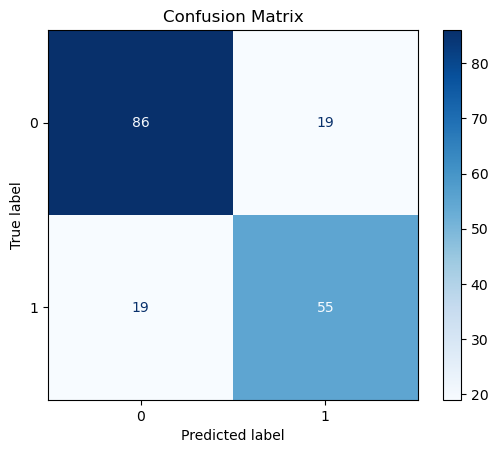

In [10]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

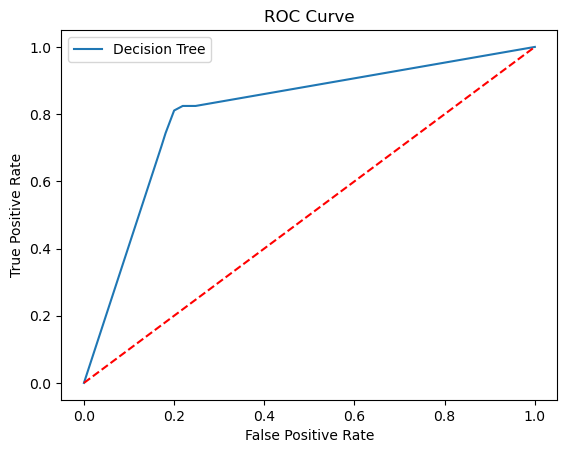

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 9. Hyperparameter Tuning

In [12]:
params = {
    "max_depth":[3,5,7,None],
    "min_samples_split":[2,5,10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Accuracy:", grid.best_score_)

Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best Accuracy: 0.8202107751403526


## 10. Result Interpretation
The Decision Tree classifier successfully classified passenger survival based on the selected features. Hyperparameter tuning improved the model by selecting the optimal tree depth and minimum samples required for splitting.

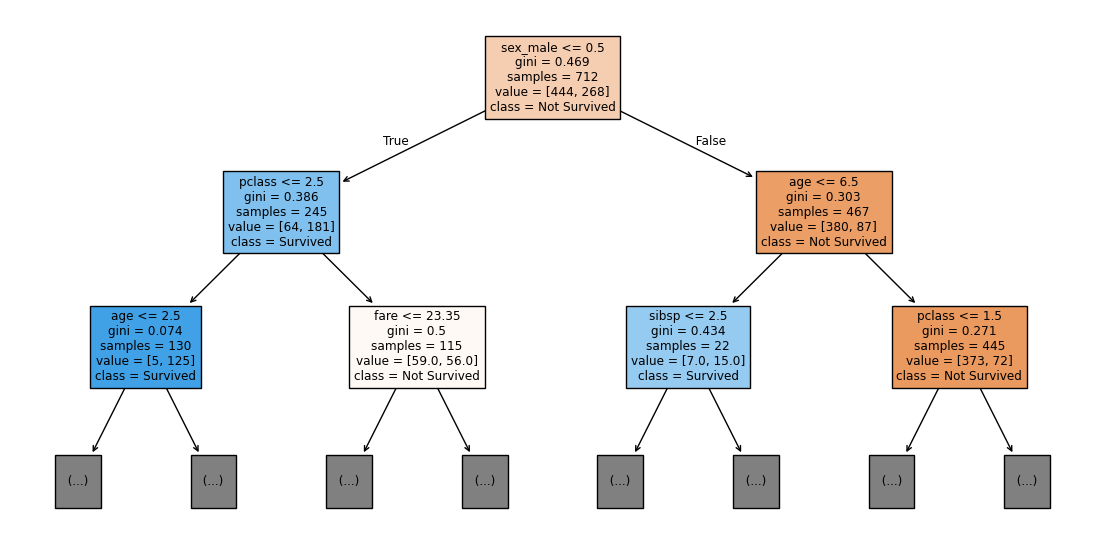

In [13]:
plt.figure(figsize=(14,7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived","Survived"],
    filled=True,
    max_depth=2
)
plt.show()

## 11. Conclusion
The Decision Tree Classifier effectively predicted passenger survival using the Titanic dataset. The model was evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, ROC Curve, and AUC Score.
    Hyperparameter tuning further improved model performance, making Decision Trees a simple and interpretable classification algorithm.